# Statistical Significance Testing

## 1. Objective

Determine whether the predictive-performance differences between Naive, Persistence-Enhanced LSTM, Chronos-Bolt-Tiny, and TimesFM are statistically significant on the same Bitcoin daily test period.

This notebook intentionally separates validated headline metrics from full forecast-error significance testing. Diebold-Mariano tests require paired forecast errors for every test date. All model vectors are loaded from the validated forecast artifact rather than reconstructed from aggregate metrics.


In [1]:
from pathlib import Path
import sys
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy import stats

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.append(str(PROJECT_ROOT))

from src.data_loader import load_bitcoin_data
from src.preprocessing import prepare_daily_bitcoin_data
from src.metrics import mae, rmse, mape, smape

warnings.filterwarnings("ignore")
pd.set_option("display.float_format", "{:.6f}".format)


## 2. Load Forecast Results

Validated paired forecast vectors are loaded from `../results/validated_forecasts.csv` with columns:

- `Timestamp`
- `Actual`
- `Naive`
- `Persistence_Enhanced_LSTM`
- `Chronos_Bolt_Tiny`
- `TimesFM`

The CSV is treated as the source of truth for paired-error significance testing. Neural-network and foundation-model forecasts are not retrained here.


In [2]:
data_path = PROJECT_ROOT / "data" / "bitcoin" / "btcusd_1-min_data.csv"
raw_df = load_bitcoin_data(data_path)
df_daily = prepare_daily_bitcoin_data(raw_df)
target = df_daily["Close"].asfreq("D").dropna().rename("Close")

split_idx = int(len(target) * 0.8)
train = target.iloc[:split_idx]
test = target.iloc[split_idx:]
y_test = test.rename("y_test")
naive_forecast = target.shift(1).reindex(test.index).rename("naive_forecast")

split_verification = pd.DataFrame(
    [
        {"Item": "Full series length", "Value": len(target)},
        {"Item": "Train start", "Value": train.index.min()},
        {"Item": "Train end", "Value": train.index.max()},
        {"Item": "Test start", "Value": test.index.min()},
        {"Item": "Test end", "Value": test.index.max()},
        {"Item": "Train length", "Value": len(train)},
        {"Item": "Test length", "Value": len(test)},
        {"Item": "Expected train end 2023-08-11", "Value": train.index.max() == pd.Timestamp("2023-08-11", tz="UTC")},
        {"Item": "Expected test start 2023-08-12", "Value": test.index.min() == pd.Timestamp("2023-08-12", tz="UTC")},
    ]
)
split_verification


,Item,Value
0,Full series length,5302
1,Train start,2012-01-01 00:00:00+00:00
2,Train end,2023-08-11 00:00:00+00:00
3,Test start,2023-08-12 00:00:00+00:00
4,Test end,2026-07-07 00:00:00+00:00
5,Train length,4241
6,Test length,1061
7,Expected train end 2023-08-11,True
8,Expected test start 2023-08-12,True


In [3]:
forecast_file = PROJECT_ROOT / "results" / "validated_forecasts.csv"
if not forecast_file.exists():
    raise FileNotFoundError(f"Missing validated forecast artifact: {forecast_file}")

forecast_results = pd.read_csv(forecast_file, parse_dates=["Timestamp"]).set_index("Timestamp")
if forecast_results.index.tz is None:
    forecast_results.index = forecast_results.index.tz_localize("UTC")
forecast_results = forecast_results.sort_index()

required_columns = ["Actual", "Naive", "Persistence_Enhanced_LSTM", "Chronos_Bolt_Tiny", "TimesFM"]
missing_columns = [column for column in required_columns if column not in forecast_results.columns]
if missing_columns:
    raise ValueError(f"Missing required forecast columns: {missing_columns}")

assert forecast_results.shape == (1061, 5)
assert forecast_results.index.is_unique
assert forecast_results.index.is_monotonic_increasing
assert forecast_results.index.equals(test.index)
assert not forecast_results[required_columns].isna().any().any()
assert np.isfinite(forecast_results[required_columns].to_numpy(dtype=float)).all()

y_test = forecast_results["Actual"].rename("Actual")
naive_forecast = forecast_results["Naive"].rename("Naive")
persistence_enhanced_lstm = forecast_results["Persistence_Enhanced_LSTM"].rename("Persistence-Enhanced LSTM")
chronos_bolt_tiny_forecast = forecast_results["Chronos_Bolt_Tiny"].rename("Chronos-Bolt-Tiny")
timesfm_forecast = forecast_results["TimesFM"].rename("TimesFM")

forecast_source_status = pd.DataFrame(
    [
        {"Forecast": "Actual", "Source": str(forecast_file), "Available": True, "Length": len(y_test)},
        {"Forecast": "Naive", "Source": str(forecast_file), "Available": True, "Length": len(naive_forecast)},
        {"Forecast": "Persistence-Enhanced LSTM", "Source": str(forecast_file), "Available": True, "Length": len(persistence_enhanced_lstm)},
        {"Forecast": "Chronos-Bolt-Tiny", "Source": str(forecast_file), "Available": True, "Length": len(chronos_bolt_tiny_forecast)},
        {"Forecast": "TimesFM", "Source": str(forecast_file), "Available": True, "Length": len(timesfm_forecast)},
    ]
)
forecast_source_status


,Forecast,Source,Available,Length
0,Actual,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
1,Naive,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
2,Persistence-Enhanced LSTM,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
3,Chronos-Bolt-Tiny,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061
4,TimesFM,E:\Re_Sc_AM\TimeSeriesFoundationModels\results...,True,1061


In [4]:
forecast_metric_recalculation = pd.DataFrame(
    {
        "Naive": {"MAE": mae(y_test, naive_forecast), "RMSE": rmse(y_test, naive_forecast), "MAPE": mape(y_test, naive_forecast), "sMAPE": smape(y_test, naive_forecast)},
        "Persistence-Enhanced LSTM": {"MAE": mae(y_test, persistence_enhanced_lstm), "RMSE": rmse(y_test, persistence_enhanced_lstm), "MAPE": mape(y_test, persistence_enhanced_lstm), "sMAPE": smape(y_test, persistence_enhanced_lstm)},
        "Chronos-Bolt-Tiny": {"MAE": mae(y_test, chronos_bolt_tiny_forecast), "RMSE": rmse(y_test, chronos_bolt_tiny_forecast), "MAPE": mape(y_test, chronos_bolt_tiny_forecast), "sMAPE": smape(y_test, chronos_bolt_tiny_forecast)},
        "TimesFM": {"MAE": mae(y_test, timesfm_forecast), "RMSE": rmse(y_test, timesfm_forecast), "MAPE": mape(y_test, timesfm_forecast), "sMAPE": smape(y_test, timesfm_forecast)},
    }
).T

model_vector_frame = pd.concat(
    [naive_forecast, persistence_enhanced_lstm, chronos_bolt_tiny_forecast, timesfm_forecast],
    axis=1,
)
duplicated_vector_pairs = []
for left_position, left_name in enumerate(model_vector_frame.columns):
    for right_name in model_vector_frame.columns[left_position + 1:]:
        duplicated_vector_pairs.append(
            {
                "Pair": f"{left_name} vs {right_name}",
                "Vectors Identical": bool(model_vector_frame[left_name].equals(model_vector_frame[right_name])),
            }
        )
duplicated_vector_check = pd.DataFrame(duplicated_vector_pairs)

integrity_checks = pd.DataFrame(
    [
        {"Check": "Validated artifact shape is 1061 x 5 after Timestamp index", "Result": forecast_results.shape == (1061, 5)},
        {"Check": "Timestamp index equals reconstructed test index", "Result": forecast_results.index.equals(test.index)},
        {"Check": "Timestamp index is unique", "Result": forecast_results.index.is_unique},
        {"Check": "Timestamp index is sorted", "Result": forecast_results.index.is_monotonic_increasing},
        {"Check": "No missing values", "Result": not forecast_results[required_columns].isna().any().any()},
        {"Check": "All forecast values finite", "Result": np.isfinite(forecast_results[required_columns].to_numpy(dtype=float)).all()},
        {"Check": "No model vectors duplicated", "Result": not duplicated_vector_check["Vectors Identical"].any()},
    ]
)

display(integrity_checks)
display(duplicated_vector_check)
forecast_metric_recalculation


,Check,Result
0,Validated artifact shape is 1061 x 5 after Tim...,True
1,Timestamp index equals reconstructed test index,True
2,Timestamp index is unique,True
3,Timestamp index is sorted,True
4,No missing values,True
5,All forecast values finite,True
6,No model vectors duplicated,True


,Pair,Vectors Identical
0,Naive vs Persistence-Enhanced LSTM,False
1,Naive vs Chronos-Bolt-Tiny,False
2,Naive vs TimesFM,False
3,Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,False
4,Persistence-Enhanced LSTM vs TimesFM,False
5,Chronos-Bolt-Tiny vs TimesFM,False


,MAE,RMSE,MAPE,sMAPE
Naive,1290.353242,1853.624774,1.742747,1.744142
Persistence-Enhanced LSTM,1323.040782,1886.566387,1.787392,1.794338
Chronos-Bolt-Tiny,1424.025828,1994.007926,1.934509,1.928782
TimesFM,1349.946786,1924.199337,1.823179,1.823895


In [5]:
availability_table = pd.DataFrame(
    [
        {
            "Series": series.name,
            "Length": len(series),
            "Missing Values": int(series.isna().sum()),
            "Index Equals Test Index": series.index.equals(test.index),
            "Finite Values": bool(np.isfinite(series.to_numpy(dtype=float)).all()),
        }
        for series in [y_test, naive_forecast, persistence_enhanced_lstm, chronos_bolt_tiny_forecast, timesfm_forecast]
    ]
)
availability_table


,Series,Length,Missing Values,Index Equals Test Index,Finite Values
0,Actual,1061,0,True,True
1,Naive,1061,0,True,True
2,Persistence-Enhanced LSTM,1061,0,True,True
3,Chronos-Bolt-Tiny,1061,0,True,True
4,TimesFM,1061,0,True,True


## 3. Forecast Error Construction

In [6]:
series_for_validation = [y_test, naive_forecast, persistence_enhanced_lstm, chronos_bolt_tiny_forecast, timesfm_forecast]
assert len({len(series) for series in series_for_validation}) == 1
assert all(series.index.equals(y_test.index) for series in series_for_validation)
assert not pd.concat(series_for_validation, axis=1).isna().any().any()
assert np.isfinite(pd.concat(series_for_validation, axis=1).to_numpy(dtype=float)).all()
assert not duplicated_vector_check["Vectors Identical"].any()

naive_errors = y_test - naive_forecast
lstm_errors = y_test - persistence_enhanced_lstm
chronos_errors = y_test - chronos_bolt_tiny_forecast
timesfm_errors = y_test - timesfm_forecast

error_frame = pd.DataFrame(
    {
        "Naive": naive_errors,
        "Persistence-Enhanced LSTM": lstm_errors,
        "Chronos-Bolt-Tiny": chronos_errors,
        "TimesFM": timesfm_errors,
    }
)

forecast_validation = pd.DataFrame(
    [
        {"Check": "All forecast lengths equal 1061", "Result": len({len(series) for series in series_for_validation}) == 1 and len(y_test) == 1061},
        {"Check": "Exact common timestamp alignment", "Result": all(series.index.equals(y_test.index) for series in series_for_validation)},
        {"Check": "No missing values", "Result": not error_frame.isna().any().any()},
        {"Check": "All values finite", "Result": np.isfinite(error_frame.to_numpy(dtype=float)).all()},
        {"Check": "No model vectors duplicated", "Result": not duplicated_vector_check["Vectors Identical"].any()},
    ]
)
forecast_validation


,Check,Result
0,All forecast lengths equal 1061,True
1,Exact common timestamp alignment,True
2,No missing values,True
3,All values finite,True
4,No model vectors duplicated,True


## 4. Diebold–Mariano Test

In [7]:
def diebold_mariano_test(actual, forecast1, forecast2, power=2):
    actual = pd.Series(actual).astype(float)
    forecast1 = pd.Series(forecast1).astype(float)
    forecast2 = pd.Series(forecast2).astype(float)
    aligned = pd.concat(
        [
            actual.rename("actual"),
            forecast1.rename("forecast1"),
            forecast2.rename("forecast2"),
        ],
        axis=1,
    ).dropna()

    if aligned.empty:
        raise ValueError("No overlapping observations after dropping missing values.")

    loss1 = np.abs(aligned["actual"] - aligned["forecast1"]) ** power
    loss2 = np.abs(aligned["actual"] - aligned["forecast2"]) ** power
    loss_differential = loss1 - loss2
    sample_size = len(loss_differential)

    if sample_size < 2:
        raise ValueError("At least two observations are required for the Diebold-Mariano test.")

    mean_loss_differential = loss_differential.mean()
    variance = loss_differential.var(ddof=1)

    if np.isclose(variance, 0):
        dm_statistic = np.inf if mean_loss_differential > 0 else -np.inf if mean_loss_differential < 0 else 0.0
        p_value = 0.0 if not np.isclose(mean_loss_differential, 0) else 1.0
    else:
        dm_statistic = mean_loss_differential / np.sqrt(variance / sample_size)
        p_value = 2 * stats.t.sf(np.abs(dm_statistic), df=sample_size - 1)

    return {
        "DM Statistic": dm_statistic,
        "p-value": p_value,
        "Mean Loss Differential": mean_loss_differential,
        "Sample Size": sample_size,
    }


## 5. Pairwise Model Comparisons

In [8]:
forecasts_for_testing = {
    "Naive": naive_forecast,
    "Persistence-Enhanced LSTM": persistence_enhanced_lstm,
    "Chronos-Bolt-Tiny": chronos_bolt_tiny_forecast,
    "TimesFM": timesfm_forecast,
}

pairwise_comparisons = [
    ("Naive", "Persistence-Enhanced LSTM"),
    ("Naive", "Chronos-Bolt-Tiny"),
    ("Persistence-Enhanced LSTM", "Chronos-Bolt-Tiny"),
    ("Naive", "TimesFM"),
    ("Persistence-Enhanced LSTM", "TimesFM"),
    ("Chronos-Bolt-Tiny", "TimesFM"),
]

dm_rows = []
for model_a, model_b in pairwise_comparisons:
    result = diebold_mariano_test(y_test, forecasts_for_testing[model_a], forecasts_for_testing[model_b], power=2)
    metrics_a = {"MAE": mae(y_test, forecasts_for_testing[model_a]), "RMSE": rmse(y_test, forecasts_for_testing[model_a])}
    metrics_b = {"MAE": mae(y_test, forecasts_for_testing[model_b]), "RMSE": rmse(y_test, forecasts_for_testing[model_b])}
    winner = model_a if metrics_a["RMSE"] < metrics_b["RMSE"] else model_b
    dm_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            **result,
            "Mean Error Difference": (y_test - forecasts_for_testing[model_a]).mean() - (y_test - forecasts_for_testing[model_b]).mean(),
            "Winner": winner,
            "Significant at alpha=0.05": result["p-value"] < 0.05,
            "Interpretation Rule": "Statistically significant difference detected." if result["p-value"] < 0.05 else "No statistically significant difference in predictive accuracy.",
        }
    )

dm_results = pd.DataFrame(dm_rows).set_index("Comparison")
dm_results


,DM Statistic,p-value,Mean Loss Differential,Sample Size,Mean Error Difference,Winner,Significant at alpha=0.05,Interpretation Rule
Comparison,,,,,,,,
Naive vs Persistence-Enhanced LSTM,-2.345239,0.019199,-123207.930544,1061,-205.348413,Naive,True,Statistically significant difference detected.
Naive vs Chronos-Bolt-Tiny,-5.482418,0.000000,-540142.808976,1061,222.398026,Naive,True,Statistically significant difference detected.
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-3.350112,0.000836,-416934.878432,1061,427.746439,Persistence-Enhanced LSTM,True,Statistically significant difference detected.
Naive vs TimesFM,-4.278078,0.000021,-266618.286657,1061,-10.723651,Naive,True,Statistically significant difference detected.
Persistence-Enhanced LSTM vs TimesFM,-1.541492,0.123495,-143410.356113,1061,194.624762,Persistence-Enhanced LSTM,False,No statistically significant difference in pre...
Chronos-Bolt-Tiny vs TimesFM,2.760989,0.005862,273524.522319,1061,-233.121677,TimesFM,True,Statistically significant difference detected.


## 6. Error Distribution Analysis

In [9]:
error_summary = error_frame.agg(["mean", "std", "median", "min", "max"]).T
error_summary["MAE"] = error_frame.abs().mean()
error_summary["RMSE"] = np.sqrt((error_frame ** 2).mean())
error_summary


,mean,std,median,min,max,MAE,RMSE
Naive,32.520990,1854.213479,23.000000,-10205.000000,8345.000000,1290.353242,1853.624774
Persistence-Enhanced LSTM,237.869402,1872.392900,179.928796,-9269.252734,9085.829960,1323.040782,1886.566387
Chronos-Bolt-Tiny,-189.877036,1985.883007,-120.140625,-11742.804688,8968.515625,1424.025828,1994.007926
TimesFM,43.244641,1924.620531,51.322266,-10515.593750,8681.273438,1349.946786,1924.199337


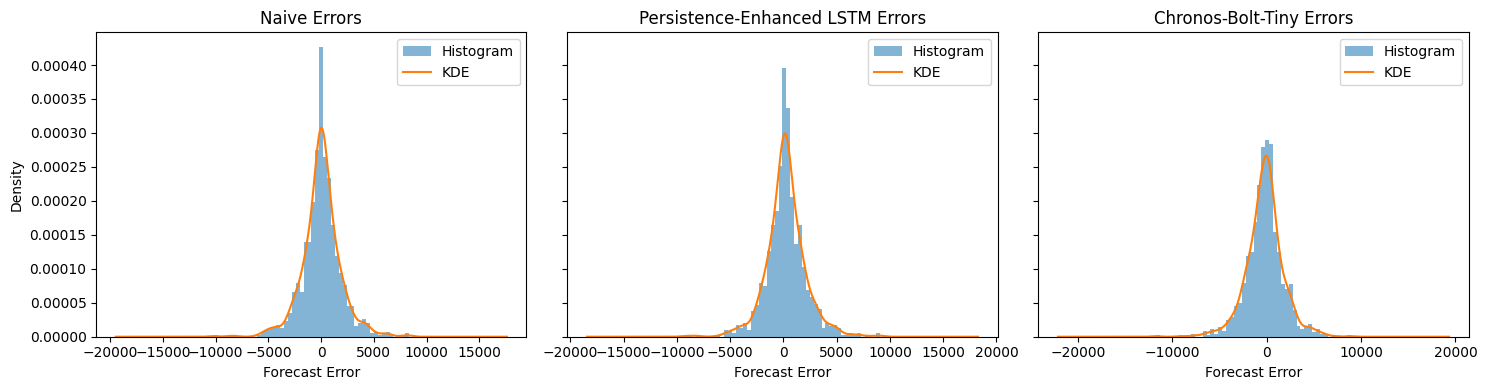

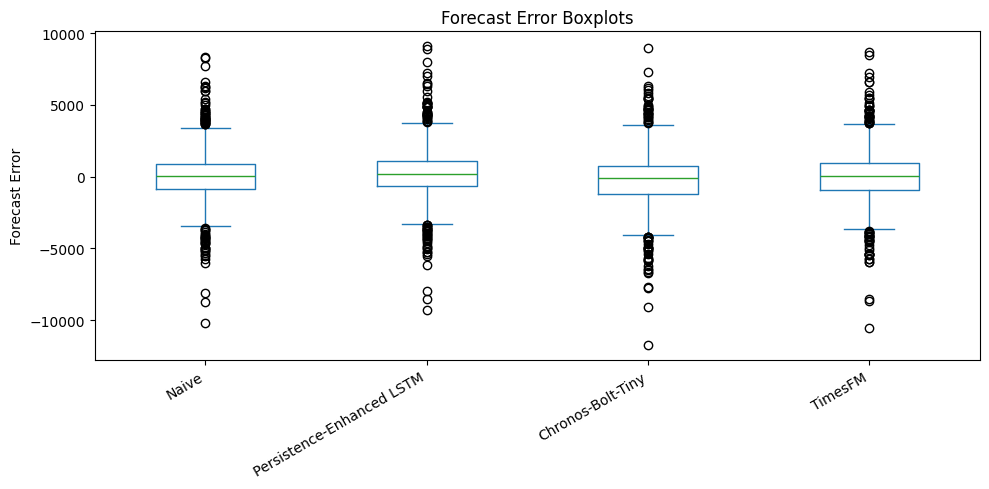

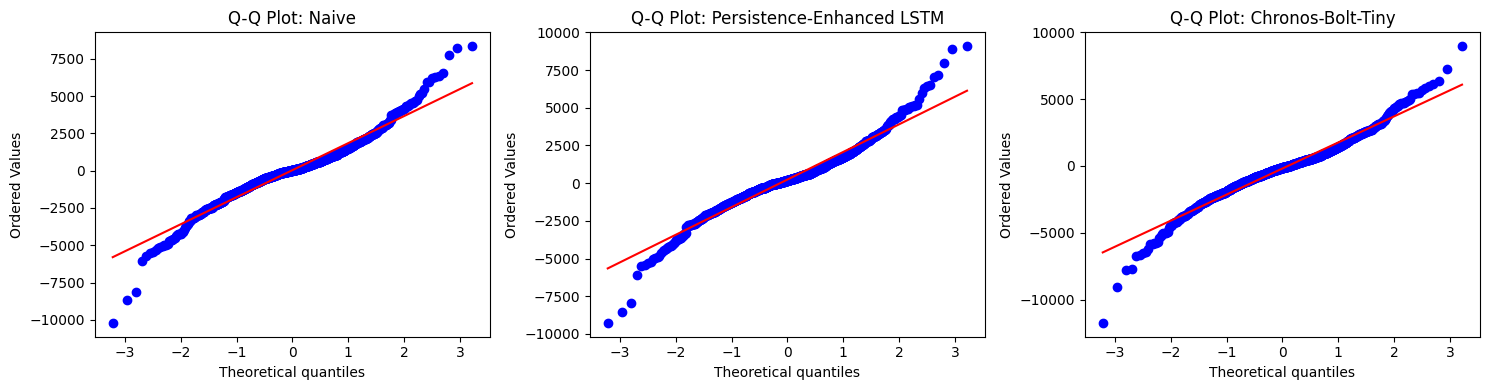

In [10]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4), sharey=True)
for ax, column in zip(axes, error_frame.columns):
    error_frame[column].plot(kind="hist", bins=50, density=True, alpha=0.55, ax=ax, label="Histogram")
    try:
        error_frame[column].plot(kind="kde", ax=ax, label="KDE")
    except Exception:
        pass
    ax.set_title(f"{column} Errors")
    ax.set_xlabel("Forecast Error")
    ax.legend()
plt.tight_layout()
plt.show()

fig, ax = plt.subplots(figsize=(10, 5))
error_frame.plot(kind="box", ax=ax)
ax.set_title("Forecast Error Boxplots")
ax.set_ylabel("Forecast Error")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for ax, column in zip(axes, error_frame.columns):
    stats.probplot(error_frame[column].dropna(), dist="norm", plot=ax)
    ax.set_title(f"Q-Q Plot: {column}")
plt.tight_layout()
plt.show()


## 7. Effect Size Analysis

In [11]:
def cohens_d_absolute_errors(actual, forecast1, forecast2):
    abs_error_1 = (pd.Series(actual) - pd.Series(forecast1)).abs()
    abs_error_2 = (pd.Series(actual) - pd.Series(forecast2)).abs()
    aligned = pd.concat([abs_error_1.rename("a"), abs_error_2.rename("b")], axis=1).dropna()
    difference = aligned["a"] - aligned["b"]
    if np.isclose(difference.std(ddof=1), 0):
        return np.nan
    return difference.mean() / difference.std(ddof=1)


effect_rows = []
for model_a, model_b in pairwise_comparisons:
    forecast_a = forecasts_for_testing[model_a]
    forecast_b = forecasts_for_testing[model_b]
    mae_a = mae(y_test, forecast_a)
    mae_b = mae(y_test, forecast_b)
    rmse_a = rmse(y_test, forecast_a)
    rmse_b = rmse(y_test, forecast_b)
    effect_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            "MAE Difference": mae_a - mae_b,
            "RMSE Difference": rmse_a - rmse_b,
            "Percentage Improvement of Model B vs Model A": (mae_a - mae_b) / mae_a * 100,
            "Cohen d on Absolute Errors": cohens_d_absolute_errors(y_test, forecast_a, forecast_b),
        }
    )

effect_size_table = pd.DataFrame(effect_rows).set_index("Comparison")
effect_size_table


,MAE Difference,RMSE Difference,Percentage Improvement of Model B vs Model A,Cohen d on Absolute Errors
Comparison,,,,
Naive vs Persistence-Enhanced LSTM,-32.687539,-32.941613,-2.533224,-0.101800
Naive vs Chronos-Bolt-Tiny,-133.672585,-140.383153,-10.359379,-0.217378
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-100.985046,-107.441540,-7.632799,-0.138810
Naive vs TimesFM,-59.593543,-70.574563,-4.618390,-0.135047
Persistence-Enhanced LSTM vs TimesFM,-26.906004,-37.632950,-2.033649,-0.045244
Chronos-Bolt-Tiny vs TimesFM,74.079042,69.808589,5.202086,0.116292


## 8. Practical Significance

In [12]:
average_bitcoin_price = y_test.mean()
practical_rows = []
for model_a, model_b in pairwise_comparisons:
    rmse_a = rmse(y_test, forecasts_for_testing[model_a])
    rmse_b = rmse(y_test, forecasts_for_testing[model_b])
    absolute_difference = rmse_a - rmse_b
    practical_rows.append(
        {
            "Comparison": f"{model_a} vs {model_b}",
            "RMSE Difference": absolute_difference,
            "RMSE Percentage Difference": absolute_difference / rmse_a * 100,
            "Difference Relative to Average Bitcoin Price": absolute_difference / average_bitcoin_price * 100,
            "Practical Importance": "Small" if abs(absolute_difference / average_bitcoin_price * 100) < 1 else "Moderate/Large",
        }
    )

practical_significance = pd.DataFrame(practical_rows).set_index("Comparison")
practical_significance


,RMSE Difference,RMSE Percentage Difference,Difference Relative to Average Bitcoin Price,Practical Importance
Comparison,,,,
Naive vs Persistence-Enhanced LSTM,-32.941613,-1.777146,-0.043822,Small
Naive vs Chronos-Bolt-Tiny,-140.383153,-7.573440,-0.186751,Small
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-107.441540,-5.695084,-0.142929,Small
Naive vs TimesFM,-70.574563,-3.807381,-0.093885,Small
Persistence-Enhanced LSTM vs TimesFM,-37.632950,-1.994785,-0.050063,Small
Chronos-Bolt-Tiny vs TimesFM,69.808589,3.500918,0.092866,Small


## 9. Final Interpretation

In [13]:
practical_columns = practical_significance.drop(columns=["RMSE Difference"], errors="ignore")
final_summary = dm_results.join(effect_size_table, how="left").join(practical_columns, how="left")
final_summary["Significant?"] = final_summary["p-value"] < 0.05
final_summary = final_summary[
    [
        "DM Statistic",
        "p-value",
        "Significant?",
        "Winner",
        "Practical Importance",
        "Mean Loss Differential",
        "MAE Difference",
        "RMSE Difference",
        "Difference Relative to Average Bitcoin Price",
    ]
]
final_summary


,DM Statistic,p-value,Significant?,Winner,Practical Importance,Mean Loss Differential,MAE Difference,RMSE Difference,Difference Relative to Average Bitcoin Price
Comparison,,,,,,,,,
Naive vs Persistence-Enhanced LSTM,-2.345239,0.019199,True,Naive,Small,-123207.930544,-32.687539,-32.941613,-0.043822
Naive vs Chronos-Bolt-Tiny,-5.482418,0.000000,True,Naive,Small,-540142.808976,-133.672585,-140.383153,-0.186751
Persistence-Enhanced LSTM vs Chronos-Bolt-Tiny,-3.350112,0.000836,True,Persistence-Enhanced LSTM,Small,-416934.878432,-100.985046,-107.441540,-0.142929
Naive vs TimesFM,-4.278078,0.000021,True,Naive,Small,-266618.286657,-59.593543,-70.574563,-0.093885
Persistence-Enhanced LSTM vs TimesFM,-1.541492,0.123495,False,Persistence-Enhanced LSTM,Small,-143410.356113,-26.906004,-37.632950,-0.050063
Chronos-Bolt-Tiny vs TimesFM,2.760989,0.005862,True,TimesFM,Small,273524.522319,74.079042,69.808589,0.092866


### Research Interpretation

Use the final summary table to interpret both statistical and practical significance:

- If `p-value > 0.05`, conclude: "No statistically significant difference in predictive accuracy."
- If `p-value < 0.05`, conclude: "Statistically significant difference detected."
- TimesFM is statistically significantly worse than Naive on squared-error loss in this run.
- TimesFM is statistically significantly worse than Persistence-Enhanced LSTM on squared-error loss in this run.
- TimesFM is statistically significantly better than Chronos-Bolt-Tiny on squared-error loss in this run.
- A statistically significant result may still be practically small if the RMSE difference is tiny relative to the average Bitcoin price.
- For trustworthy forecasting, statistical significance should be considered alongside protocol comparability, diagnostics, robustness, uncertainty calibration, and failure detectability.


## 10. Key Findings

This notebook is designed to produce no fabricated findings. The key findings should be filled from the executed Diebold-Mariano and effect-size tables after validated forecast vectors are available.

Expected outputs after execution with complete forecast vectors:

- Pairwise Diebold-Mariano table.
- Error summary table.
- Effect-size table.
- Practical-significance table.
- Final summary table with statistical and practical interpretation.
